# UQ in one working example

**Predict a sensor reading, give it a useful interval, and measure how reliable that interval is.**

You need basic Python, averages, and the idea of a probability. Run the cells
in order; everything uses NumPy and Matplotlib. The data are generated here.

## 1. Start with a prediction

A sensor responds to an input $x$. Its readings follow

$$Y=1+2x+\eta,\qquad \eta\sim\mathcal N(0,0.5^2).$$

The noise standard deviation is $0.5$. Even at the same input, successive
readings differ. We will generate data from this rule, then learn a line from
the data as if its coefficients were unknown.

There are two sources of uncertainty: the random noise in the next reading
(*aleatoric uncertainty*) and our imperfect knowledge of the response curve
(*epistemic uncertainty*). More training data helps us learn the curve; the
next reading still has noise.


In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt

SEED = 20260919
ALPHA = 0.025       # target prediction miss rate
EPSILON = 0.005     # desired coverage error: 0.5 percentage points
DELTA = 0.05        # error probability for the coverage measurement

streams = np.random.SeedSequence(SEED).spawn(3)
train_rng, cal_rng, test_rng = [np.random.default_rng(s) for s in streams]

def sensor(rng, n):
    x = rng.uniform(-1, 1, n)
    y = 1 + 2*x + rng.normal(0, 0.5, n)
    return x, y

plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 11})


Fit the line $\widehat f(x)=b_0+b_1x$ with least squares. The two columns of
the design matrix represent the intercept and the slope.


In [2]:
x_train, y_train = sensor(train_rng, 200)
design = np.column_stack([np.ones(len(x_train)), x_train])
b0, b1 = np.linalg.lstsq(design, y_train, rcond=None)[0]

def predict(x):
    return b0 + b1*np.asarray(x)

print(f"Learned response: {b0:.3f} + {b1:.3f} x")
print(f"At x = 0.5, predict {predict(0.5):.3f}")


Learned response: 0.981 + 1.912 x
At x = 0.5, predict 1.937


A point prediction gives one number. UQ adds a range for a future reading.
That prediction range includes observation noise; a confidence interval for
the mean response would answer a different question.

## 2. Turn errors into a prediction interval

Use **4,000 new calibration observations** to see how large prediction errors
are. Keep these observations separate from the training data.

For each one, calculate its absolute error:

$$r_i=|y_i-\widehat f(x_i)|.$$

Choose a target miss rate $\alpha$. With $m$ calibration errors, take the
$k$th smallest error, where

$$k=\lceil(m+1)(1-\alpha)\rceil.$$

Call that error $q$. Our prediction interval is

$$C(x)=[\widehat f(x)-q,\ \widehat f(x)+q].$$

This is **split conformal prediction**. The small rank adjustment makes the
coverage guarantee valid for finite samples. We use a target coverage of
97.5% ($\alpha=0.025$); setting a higher target generally widens the interval.


In [3]:
x_cal, y_cal = sensor(cal_rng, 4000)
residuals = np.abs(y_cal - predict(x_cal))
k = math.ceil((len(residuals) + 1) * (1 - ALPHA))
q = float(np.partition(residuals, k - 1)[k - 1]) if k <= len(residuals) else math.inf

print(f"Calibration rank: {k:,} of {len(residuals):,}")
print(f"Prediction half-width: {q:.3f}")
print(f"At x = 0.5: [{predict(0.5)-q:.3f}, {predict(0.5)+q:.3f}]")


Calibration rank: 3,901 of 4,000
Prediction half-width: 1.118
At x = 0.5: [0.819, 3.055]


**The guarantee:** for independent calibration and future observations from
the same distribution, with the fitted model kept fixed,
$\Pr\{Y_{\mathrm{new}}\in C(X_{\mathrm{new}})\}\geq1-\alpha$.
This probability averages over the calibration sample and the future
observation. It is an overall coverage guarantee, rather than a separate
guarantee at each input $x$.
[Method reference: Angelopoulos and Bates, Section 1.1](https://arxiv.org/abs/2107.07511).


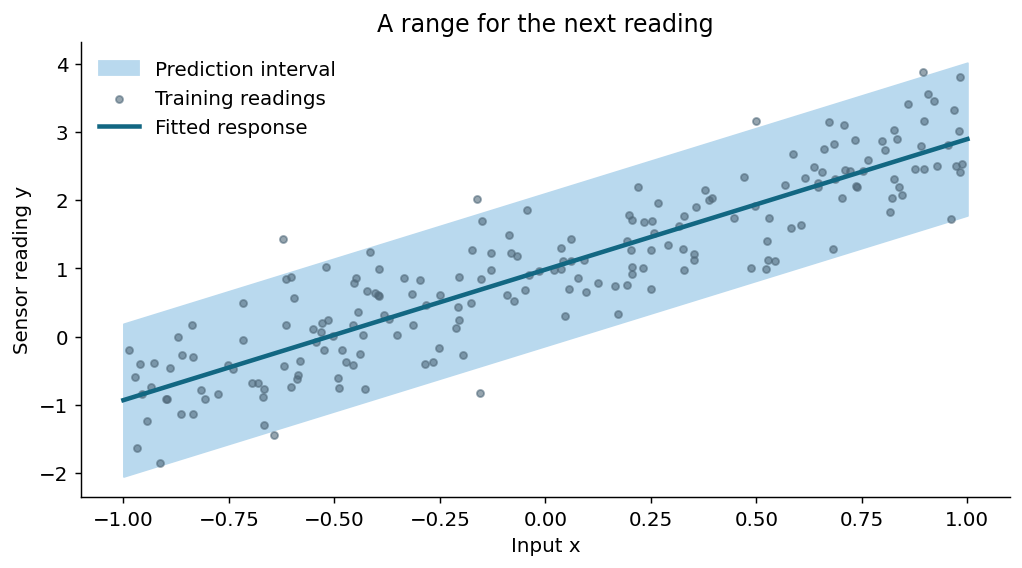

In [4]:
grid = np.linspace(-1, 1, 250)
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.fill_between(grid, predict(grid)-q, predict(grid)+q,
                color="#b9d9ee", label="Prediction interval")
ax.scatter(x_train, y_train, s=15, alpha=0.6, color="#516a7b",
           label="Training readings")
ax.plot(grid, predict(grid), color="#126782", lw=2.5, label="Fitted response")
ax.set(xlabel="Input x", ylabel="Sensor reading y",
       title="A range for the next reading")
ax.legend(frameon=False, loc="upper left")
fig.tight_layout()
plt.show()


The band has constant width because this example uses a single residual
threshold. Its width describes variation in future readings.

## 3. Decide how precisely to measure coverage

Freeze the fitted line and the calibrated band. Let $p$ be the chance that
this particular band contains a fresh reading. We can estimate $p$ by
generating $n$ independent readings and counting the fraction inside it:

$$\widehat p=\frac{1}{n}\sum_{i=1}^{n}
\mathbf 1\{y_i\in C(x_i)\}.$$

The indicator is 1 for a reading inside the band and 0 otherwise. Since
these indicators are independent and bounded, **Hoeffding's inequality** gives

$$\Pr\{|\widehat p-p|>\epsilon\}\leq2e^{-2n\epsilon^2}.$$

Use this as a measurement-planning tool. For error at most $\epsilon$ with
confidence at least $1-\delta$, choose

$$n=\left\lceil\frac{\log(2/\delta)}{2\epsilon^2}\right\rceil.$$

We choose **±0.5 percentage points at 95% confidence**. The sample size is
set before collecting the measurement data.
[Bound reference: Hoeffding (1963)](https://www.cs.rpi.edu/academics/courses/spring06/random/hoefding.pdf).


In [5]:
n_test = math.ceil(math.log(2/DELTA) / (2*EPSILON**2))
error = math.sqrt(math.log(2/DELTA) / (2*n_test))
print(f"Fresh measurements to collect: {n_test:,}")
print(f"Coverage error bar: ±{100*error:.3f} percentage points")
print(f"Confidence level: {100*(1-DELTA):.0f}%")


Fresh measurements to collect: 73,778
Coverage error bar: ±0.500 percentage points
Confidence level: 95%


## 4. Collect the measurements

Each fresh pair $(x,y)$ is one independent measurement. We measure the
coverage of the same fitted and calibrated predictor throughout.


In [6]:
x_test, y_test = sensor(test_rng, n_test)
covered = np.abs(y_test - predict(x_test)) <= q
p_hat = float(np.mean(covered))
lower, upper = max(0.0, p_hat-error), min(1.0, p_hat+error)

print(f"Readings inside the interval: {int(covered.sum()):,} / {n_test:,}")
print(f"Measured coverage: {100*p_hat:.2f}%")
print(f"{100*(1-DELTA):.0f}% confidence interval for coverage: "
      f"[{100*lower:.2f}%, {100*upper:.2f}%]")
print(f"Prediction interval width: {2*q:.3f} sensor units")


Readings inside the interval: 71,854 / 73,778
Measured coverage: 97.39%
95% confidence interval for coverage: [96.89%, 97.89%]
Prediction interval width: 2.236 sensor units


With the default seed, **71,854 of 73,778** readings fall inside the band:
**97.39% coverage**, with a **[96.89%, 97.89%]** confidence interval. The
prediction band is **2.236 sensor units** wide.

These outputs describe two different intervals:

| Interval | Units | What it describes |
|---|---|---|
| $[\widehat f(x)-q,\widehat f(x)+q]$ | Sensor units | A range for the next reading |
| $[\widehat p-\epsilon_n,\widehat p+\epsilon_n]$, clipped to $[0,1]$ | Probability | Uncertainty in measured coverage |

Here $\epsilon_n=\sqrt{\log(2/\delta)/(2n)}$. The second interval contains the
fixed predictor's true coverage in at least 95% of repetitions of the fresh
measurement experiment. It does not say that the first interval covers 95%
of readings: the coverage estimate is the number printed above.

## 5. Turn the right knob

More fresh measurements make the **coverage estimate** more precise. At fixed
confidence, multiplying $n$ by four halves its error bar.


Desired error (percentage points) | Measurements
                            2.0 |        4,612
                            1.0 |       18,445
                            0.5 |       73,778


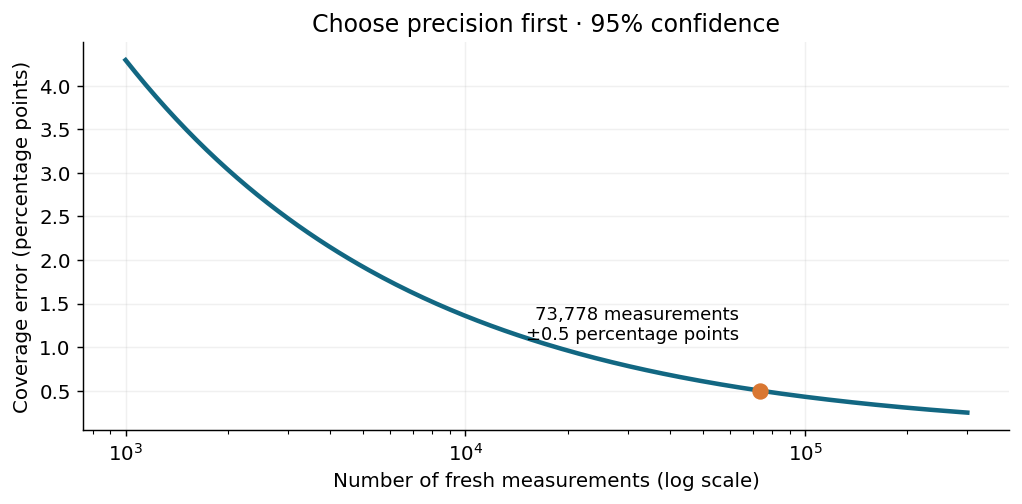

In [7]:
print("Desired error (percentage points) | Measurements")
for eps in [0.02, 0.01, 0.005]:
    budget = math.ceil(math.log(2/DELTA) / (2*eps**2))
    print(f"{100*eps:31.1f} | {budget:12,}")

sizes = np.geomspace(1000, 300000, 250)
radii = 100*np.sqrt(math.log(2/DELTA)/(2*sizes))
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(sizes, radii, color="#126782", lw=2.5)
ax.scatter([n_test], [100*error], color="#d97732", s=65, zorder=3)
ax.annotate(f"{n_test:,} measurements\n±{100*error:.1f} percentage points",
            (n_test, 100*error), xytext=(-12, 28), textcoords="offset points",
            ha="right", fontsize=10)
ax.set_xscale("log")
ax.set(xlabel="Number of fresh measurements (log scale)",
       ylabel="Coverage error (percentage points)",
       title=f"Choose precision first · {100*(1-DELTA):.0f}% confidence")
ax.grid(alpha=0.18)
fig.tight_layout()
plt.show()


The **prediction interval's width** has a different control: its target
coverage. Compare widths using the same calibration errors:


In [8]:
print("Target prediction coverage | Interval width (sensor units)")
for alpha in [0.10, 0.05, 0.025]:
    rank = math.ceil((len(residuals)+1)*(1-alpha))
    half_width = float(np.partition(residuals, rank-1)[rank-1])
    print(f"{100*(1-alpha):25.1f}% | {2*half_width:29.3f}")


Target prediction coverage | Interval width (sensor units)
                     90.0% |                         1.646
                     95.0% |                         1.953
                     97.5% |                         2.236


| Change | Effect |
|---|---|
| Lower $\alpha$ | Higher target prediction coverage; generally wider bands |
| Lower $\epsilon$ | More measurements; more precise coverage estimates |
| Lower $\delta$ | Higher confidence; more measurements at the same precision |
| More training data | Better knowledge of the response curve |
| More calibration data | A more stable estimate of the residual threshold |

Extra measurement data does not change the prediction band. To improve the
band, improve the predictor or its calibration. To measure its coverage more
precisely, increase the measurement budget.

## Try it

1. Set `EPSILON = 0.0025` and rerun. The budget becomes 295,111 measurements;
   the coverage error bar halves, while the prediction band stays the same.
2. Set `ALPHA = 0.10` and rerun. The band narrows and its target coverage
   becomes 90%; the Hoeffding measurement budget stays the same.
3. Set `DELTA = 0.01` and rerun. The measurement confidence becomes 99%,
   requiring 105,967 readings at the original precision.

For a final reported result, choose these settings before drawing the fresh
measurement sample. If you use measurements to select a model, collect a new
sample for its final coverage estimate. The guarantees here assume independent
observations from the same distribution; use independent units when adapting
the example to repeated readings, images, or subjects.

You now have a complete UQ workflow: fit a predictor, calibrate its prediction
interval, choose a measurement precision, and report coverage together with
interval width.
